# 03 · MLP — V_in=5, V_out=5
### Taller B3-T4 — Redes Neuronales para Forecasting

Notebook individual para **una única combinación** del bucle 4×4. Forma parte de la familia de 16 notebooks `mlp_vin{V}_vout{V}.ipynb` en `03_mlp/`.

Patrón "1 notebook = 1 combo": se entrena el MLP sobre ventanas (V_in=5 → V_out=5) y se guarda **un único resultado parcial** y la curva de entrenamiento. El consolidado de los 16 parciales y los heatmaps los genera `_agregador_mlp.ipynb`.

---

**Salidas generadas por este notebook**

| Carpeta | Fichero | Contenido |
|---|---|---|
| `08_results/tablas/parciales/` | `mlp_vin5_vout5.csv` | 1 fila: modelo, v_in, v_out, n_params, mae_train, mae_val, mae_test |
| `08_results/curvas/mlp/` | `mlp_vin5_vout5.png` | Curva loss/val_loss |

> ⚠️ La partición train/val/test usa `random_state=42` (cronológica) — **no modificar**.  
> ⚠️ Para cambiar de combo: duplicar este notebook y modificar **solo** `V_IN, V_OUT` en la celda de constantes.

## 1. Entorno de ejecución

Detección automática Colab / local, montaje de Drive si procede, e inserción de `01_src_compartido` en `sys.path`.

In [39]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

> Entorno : local
> BASE    : /mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX
> SRC     : /mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX/01_src_compartido


## 2. Importaciones

Librerías estándar, Keras y módulos compartidos del proyecto. Se inyecta `BASE` en `metrics_utils` para que las funciones de guardado escriban en la ruta correcta.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau

from dataset_utils import load_data, create_dataset, get_partitions, TICKERS
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import calc_mae_all, plot_curva, guardar_resultado_parcial

print(f'> TensorFlow : {tf.__version__}')
print(f'> GPU        : {tf.config.list_physical_devices("GPU")}')

> TensorFlow : 2.13.0
> GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Configuración de este notebook

**Esta es la única celda que cambia entre notebooks de la misma arquitectura.** Para crear `mlp_vin5_vout5.ipynb`, duplicar este fichero y cambiar `V_OUT = 5`.

In [41]:
MODELO = 'MLP'
V_IN, V_OUT = 10, 1
n_assets = len(TICKERS)

print(f'> Combinación: V_in={V_IN}, V_out={V_OUT}')

> Combinación: V_in=10, V_out=1


## 4. Descarga de datos y construcción del dataset

Precios de cierre ajustados de los 23 activos del S&P 500 vía `yfinance`, transformados a log-retornos. Se construyen las ventanas para esta combinación y se particiona cronológicamente (semilla competición = 42).

In [42]:
data, df = load_data()
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

X, Y = create_dataset(data, V_IN, V_OUT)
X_tr, X_val, X_test, Y_tr, Y_val, Y_test = get_partitions(X, Y, val_size=0.1, test_size=0.1)

print(f'> X shape: {X.shape}   Y shape: {Y.shape}')
print(f'> Train: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

> Datos : 16,195 días × 23 activos
> Rango : 1962-01-03 → 2026-05-08
> X shape: (16185, 10, 23)   Y shape: (16185, 23)
> Train: 13,109  Val: 1,457  Test: 1,619


## 5. Definición del modelo MLP

Red densa de dos capas ocultas. La entrada `(V_IN, 23)` se aplana antes de las capas Dense. Loss y métrica: `mae`.

In [43]:
model = keras.Sequential([
    layers.Input(shape=(V_IN, n_assets)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    #layers.Dropout(0.3),
    layers.Dense(n_assets, activation='relu'),
    #layers.Dropout(0.3),
    #layers.Dense(n_assets)
])
model.compile(optimizer='adam', loss='mae', metrics=['mae'])

model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


 flatten_6 (Flatten)         (None, 230)               0         
                                                                 
 dense_13 (Dense)            (None, 128)               29568     
                                                                 
 dense_14 (Dense)            (None, 23)                2967      
                                                                 
Total params: 32535 (127.09 KB)
Trainable params: 32535 (127.09 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Entrenamiento

`ReduceLROnPlateau` reduce el LR cuando `val_loss` se estanca. Sin bucle: solo esta combinación.

In [ ]:
EPOCHS     = 50
#BATCH_SIZE = 256

rlr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.1, patience=2,
    min_lr=1e-6, verbose=0
)

history = model.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    #batch_size=BATCH_SIZE,
    callbacks=[rlr],
    verbose=1,
)


In [47]:

print(f'> Epochs entrenadas: {len(history.history["loss"])}')
print(f'> Best val_loss   : {min(history.history["val_loss"]):.5f}')

> Epochs entrenadas: 50
> Best val_loss   : 0.00903


In [48]:
# Realizar predicciones en el conjunto de prueba. 
Y_pred = model.predict(X_test)

51/51 [==============================] - 0s 2ms/step


In [49]:
Y_pred

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

## 7. Métricas y persistencia

Calcula MAE en train, val y test. Guarda la curva de entrenamiento y el resultado parcial (1 CSV con 1 fila). El agregador `_agregador_mlp.ipynb` consolidará después los 16 parciales en `mlp_resultados.csv` y generará los heatmaps.

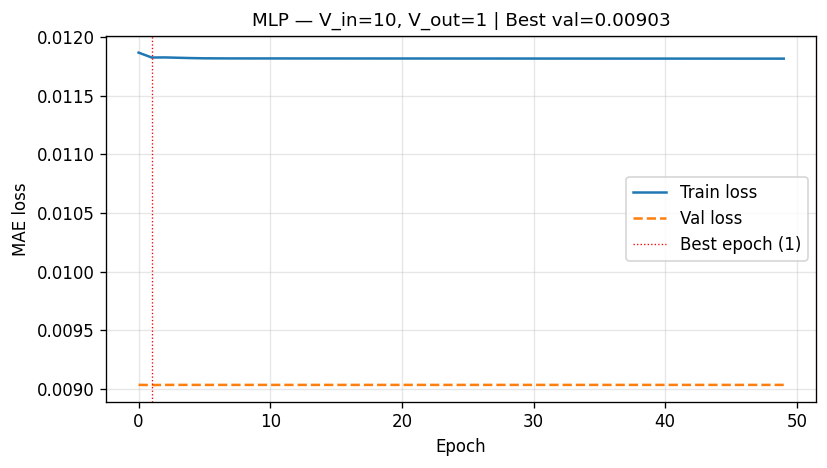

> Resultado parcial guardado: /mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX/08_results/tablas/parciales/mlp_vin10_vout1.csv
modelo  v_in  v_out  n_params  mae_train  mae_val  mae_test
   MLP    10      1     32535   0.011814 0.009034  0.012283

> MAE  train=0.0118  val=0.0090  test=0.0123  params=32,535


In [46]:
maes = calc_mae_all(model, X_tr, Y_tr, X_val, Y_val, X_test, Y_test)

plot_curva(history, MODELO, V_IN, V_OUT, save=True)
plt.show()

resultado = {
    'modelo':    MODELO,
    'v_in':      V_IN,
    'v_out':     V_OUT,
    'n_params':  model.count_params(),
    'mae_train': maes['train'],
    'mae_val':   maes['val'],
    'mae_test':  maes['test'],
}

ruta = guardar_resultado_parcial(resultado, MODELO, V_IN, V_OUT, verbose=True)

print(f'\n> MAE  train={maes["train"]:.4f}  val={maes["val"]:.4f}  test={maes["test"]:.4f}'
      f'  params={model.count_params():,}')